In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit, cross_validate
from ElectricSequentialRegressor import ElectricSequentialRegressor
from xgboost import XGBRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
from Utils import mse_column_score, plot_performance_analysis, shifted_mape, plot_params_vs_mse
import joblib

In [2]:
X = pd.read_csv('dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
Y = pd.read_csv('dataset/dataset_out.txt', index_col=0).loc[:, ['PERD', 'QGEN7']]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]
#NORMALIZACIÓN DE ATRIBUTOS PARA FACILITAR COMPARACIÓN ENTRE MODELOS
normalizer_X = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(normalizer_X.fit_transform(X), columns=X.columns, index=X.index)

In [3]:
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

In [4]:
random_model = ElectricSequentialRegressor(XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42),
                                           XGBRegressor(objective='reg:squarederror', n_jobs=1, random_state=42))
random_grid = {
    'estimator1__n_estimators': randint(30, 101),
    'estimator1__max_depth': randint(3, 9),
    'estimator1__learning_rate': uniform(0.01, 0.2),
    'estimator1__colsample_bytree': uniform(0.4, 0.5),
    'estimator2__n_estimators': randint(80, 251),
    'estimator2__max_depth': randint(4, 11),
    'estimator2__learning_rate': uniform(0.01, 0.2),
    'estimator2__colsample_bytree': uniform(0.4, 0.5)
}
random_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_perd': make_scorer(mse_column_score, col_idx=0, greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=1, greater_is_better=False),
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring=random_scoring, refit='mse_global',
                                   n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [5]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,"ElectricSeque...ee=None, ...))"
,param_distributions,"{'estimator1__colsample_bytree': <scipy.stats....0020AB4920A10>, 'estimator1__learning_rate': <scipy.stats....0020AB4920490>, 'estimator1__max_depth': <scipy.stats....0020AB4903E50>, 'estimator1__n_estimators': <scipy.stats....0020AB3E15610>, ...}"
,n_iter,30
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_perd': make_scorer(m...t', col_idx=0), 'mse_qgen7': make_scorer(m...t', col_idx=1)}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [6]:
best_random_model = random_search.best_estimator_
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['param_estimator1__max_depth', 'param_estimator1__colsample_bytree', 'param_estimator1__learning_rate', 'param_estimator1__n_estimators', 'param_estimator2__max_depth', 'param_estimator2__colsample_bytree', 'param_estimator2__learning_rate', 'param_estimator2__n_estimators', 'mean_test_mse_global', 'mean_test_mse_perd', 'mean_test_mse_qgen7']]

MSE: -0.07436466092864673


,param_estimator1__max_depth,param_estimator1__colsample_bytree,param_estimator1__learning_rate,param_estimator1__n_estimators,param_estimator2__max_depth,param_estimator2__colsample_bytree,param_estimator2__learning_rate,param_estimator2__n_estimators,mean_test_mse_global,mean_test_mse_perd,mean_test_mse_qgen7
0,5,0.587270,0.200143,90,10,0.698425,0.099167,154,-0.133830,-0.267346,-0.000315
1,5,0.629624,0.076742,51,9,0.428206,0.154400,117,-0.125523,-0.250707,-0.000341
2,3,0.400389,0.208442,87,4,0.662378,0.096389,138,-0.137357,-0.274377,-0.000338
3,6,0.599930,0.019333,44,6,0.628035,0.167035,187,-0.089301,-0.177465,-0.001137
4,5,0.657117,0.128483,80,5,0.740154,0.100100,211,-0.077885,-0.155456,-0.000314
5,4,0.871101,0.122658,38,7,0.407983,0.056179,190,-0.101954,-0.203578,-0.000332
6,5,0.741632,0.131999,65,9,0.491118,0.161072,213,-0.118726,-0.237137,-0.000314
7,7,0.503971,0.123540,92,5,0.821142,0.099951,93,-0.151275,-0.302231,-0.000320
8,8,0.763636,0.075308,91,5,0.562665,0.087735,190,-0.087527,-0.174744,-0.000312
9,6,0.814369,0.081351,89,10,0.671348,0.038185,124,-0.179874,-0.359443,-0.000307


In [7]:
random_predictions = best_random_model.predict(x_test)
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
pd.DataFrame(random_data_score, columns=['PERD', 'QGEN7'], index=['MAE', 'MAPE', 'R2'])

,PERD,QGEN7
MAE,0.236427,0.016979
MAPE,0.026941,0.015958
R2,0.977467,0.796058


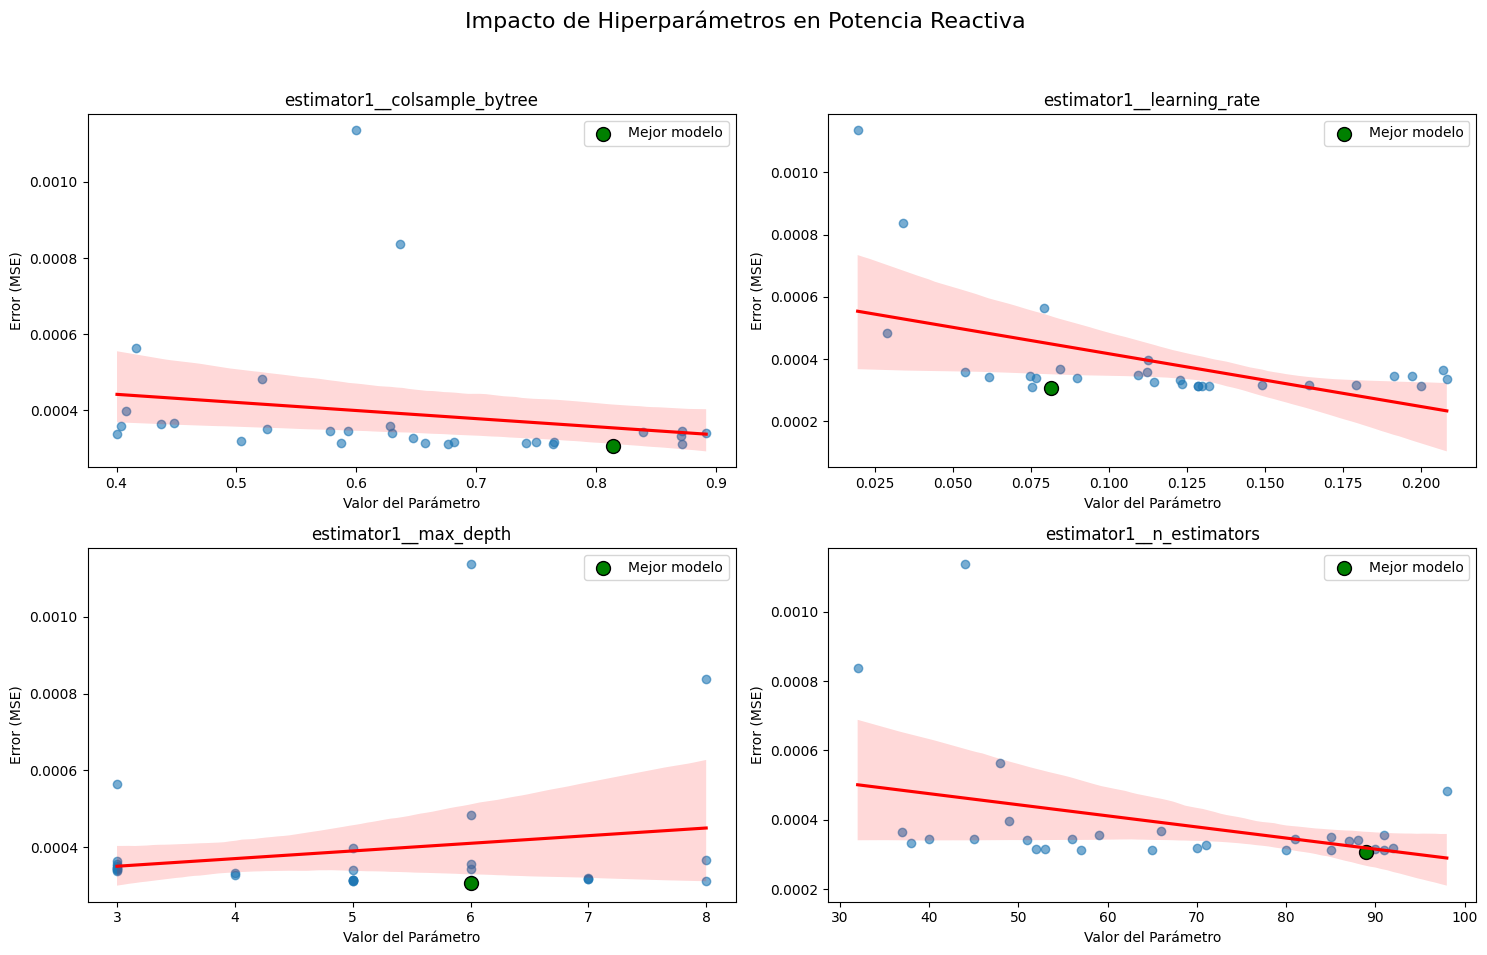

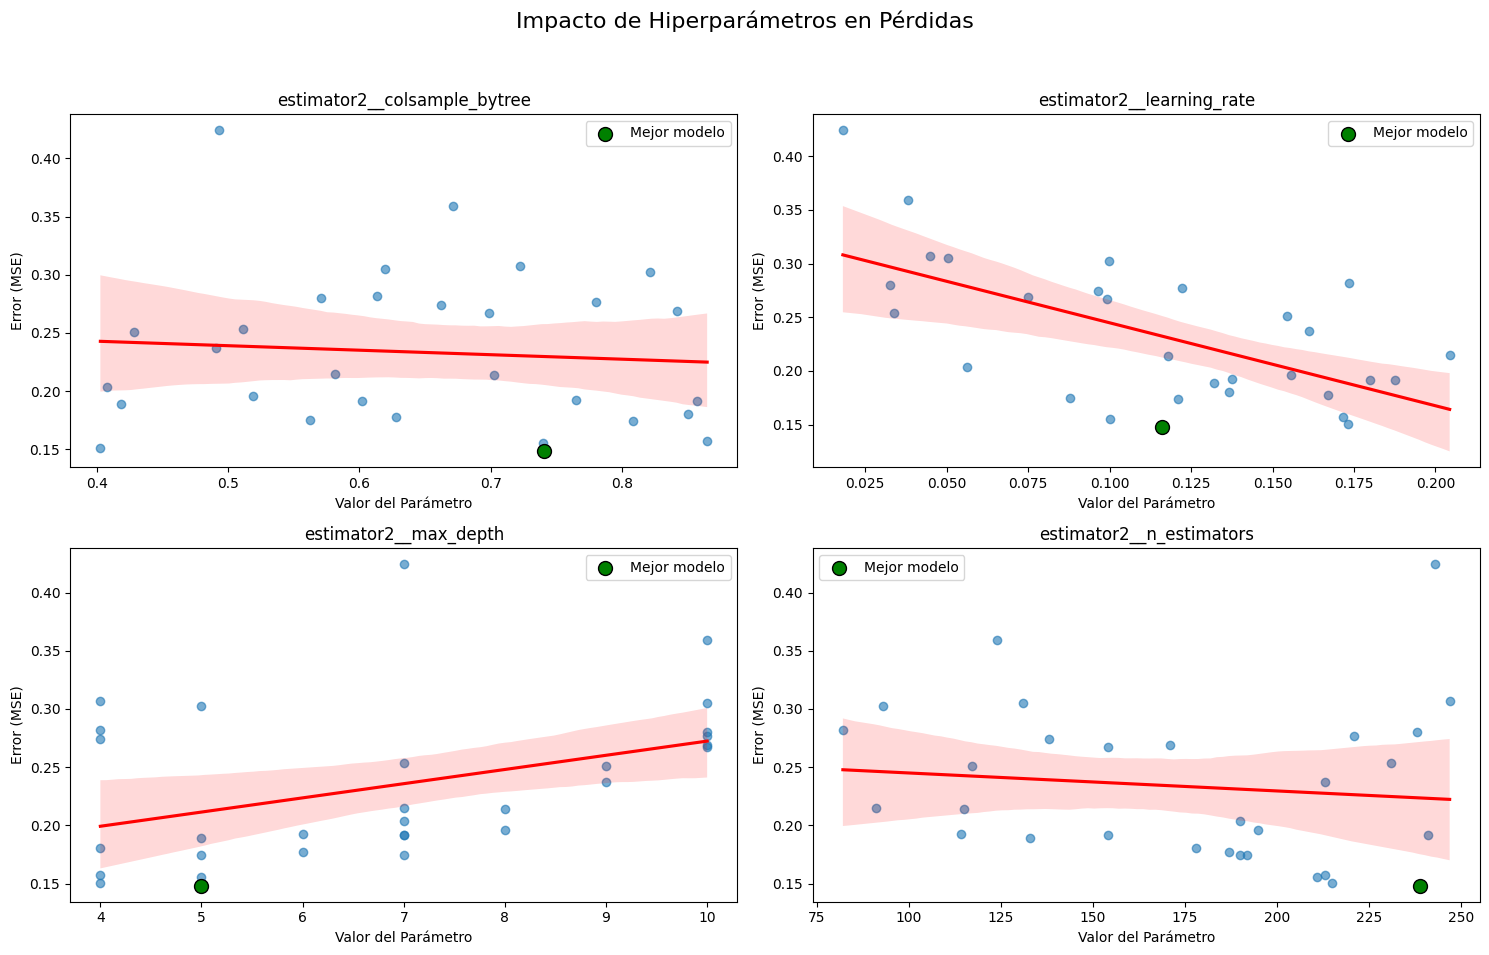

In [8]:
random_param_cols = [p for p in random_results if 'param_' in p]
plot_params_vs_mse(random_results, 'mean_test_mse_qgen7', 'estimator1', random_param_cols, 'Potencia Reactiva')
plot_params_vs_mse(random_results, 'mean_test_mse_perd', 'estimator2', random_param_cols, 'Pérdidas')

In [9]:
grid_model = ElectricSequentialRegressor(XGBRegressor(objective='reg:squarederror', colsample_bytree=0.8, n_jobs=1, random_state=42),
                                           XGBRegressor(objective='reg:squarederror', colsample_bytree=0.8, n_jobs=1, random_state=42))
grid = {
    'estimator1__n_estimators': [80, 90, 100],
    'estimator1__max_depth': [3, 4, 6],
    'estimator1__learning_rate': [0.075, 0.125],
    'estimator2__n_estimators': [190, 240, 300],
    'estimator2__max_depth': [4, 5, 6],
    'estimator2__learning_rate': [0.125, 0.175]
}
grid_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_perd': make_scorer(mse_column_score, col_idx=0, greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=1, greater_is_better=False),
}
grid_search = GridSearchCV(grid_model, grid, scoring=grid_scoring, cv=TimeSeriesSplit(n_splits=3), n_jobs=-1, verbose=2, return_train_score=True, refit='mse_global')

In [10]:
grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 324 candidates, totalling 972 fits


,estimator,"ElectricSeque...ee=None, ...))"
,param_grid,"{'estimator1__learning_rate': [0.075, 0.125], 'estimator1__max_depth': [3, 4, ...], 'estimator1__n_estimators': [80, 90, ...], 'estimator2__learning_rate': [0.125, 0.175], ...}"
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_perd': make_scorer(m...t', col_idx=0), 'mse_qgen7': make_scorer(m...t', col_idx=1)}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,objective,'reg:squarederror'


In [11]:
best_grid_model = grid_search.best_estimator_
print('MSE: ' + str(grid_search.best_score_))
grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results.loc[:, ['param_estimator1__max_depth', 'param_estimator1__n_estimators', 'param_estimator2__max_depth', 'param_estimator2__n_estimators', 'mean_test_mse_global', 'mean_test_mse_perd', 'mean_test_mse_qgen7']]

MSE: -0.06940584133068721


,param_estimator1__max_depth,param_estimator1__n_estimators,param_estimator2__max_depth,param_estimator2__n_estimators,mean_test_mse_global,mean_test_mse_perd,mean_test_mse_qgen7
0,3,80,4,190,-0.089344,-0.178339,-0.000349
1,3,80,4,240,-0.078958,-0.157568,-0.000349
2,3,80,4,300,-0.072337,-0.144326,-0.000349
3,3,80,5,190,-0.082402,-0.164456,-0.000349
4,3,80,5,240,-0.076192,-0.152036,-0.000349
...,...,...,...,...,...,...,...
319,6,100,5,240,-0.076343,-0.152378,-0.000308
320,6,100,5,300,-0.073223,-0.146137,-0.000308
321,6,100,6,190,-0.083794,-0.167281,-0.000308
322,6,100,6,240,-0.080993,-0.161678,-0.000308


In [12]:
grid_predictions = best_grid_model.predict(x_test)
grid_MAE = mean_absolute_error(y_test, grid_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
grid_MAPE = mean_absolute_percentage_error(y_test + 1.0, grid_predictions + 1.0, multioutput='raw_values')
grid_R2 = r2_score(y_test, grid_predictions, multioutput='raw_values')
grid_data_score = np.vstack([grid_MAE, grid_MAPE, grid_R2])
pd.DataFrame(grid_data_score, columns=['PERD', 'QGEN7'], index=['MAE', 'MAPE', 'R2'])

,PERD,QGEN7
MAE,0.235580,0.006938
MAPE,0.027373,0.006531
R2,0.977841,0.885745


In [13]:
joblib.dump(best_grid_model, 'modelos/ESR_XGBoost.pkl')

['modelos/ESR_XGBoost.pkl']

In [15]:
grid_search.best_params_

{'estimator1__learning_rate': 0.075,
 'estimator1__max_depth': 6,
 'estimator1__n_estimators': 80,
 'estimator2__learning_rate': 0.175,
 'estimator2__max_depth': 4,
 'estimator2__n_estimators': 300}

In [16]:
evaluate_model = ElectricSequentialRegressor(XGBRegressor(objective='reg:squarederror', colsample_bytree=0.8, learning_rate=0.075, max_depth=6, n_estimators=80, n_jobs=1, random_state=42),
                                           XGBRegressor(objective='reg:squarederror', colsample_bytree=0.8, learning_rate=0.175, max_depth=4, n_estimators=300, n_jobs=1, random_state=42))
evaluate_scoring = {
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.08348977938294411
MAE: 0.12497773170471191
MAPE: 0.017371996312819448
R2: 0.9376704096794128


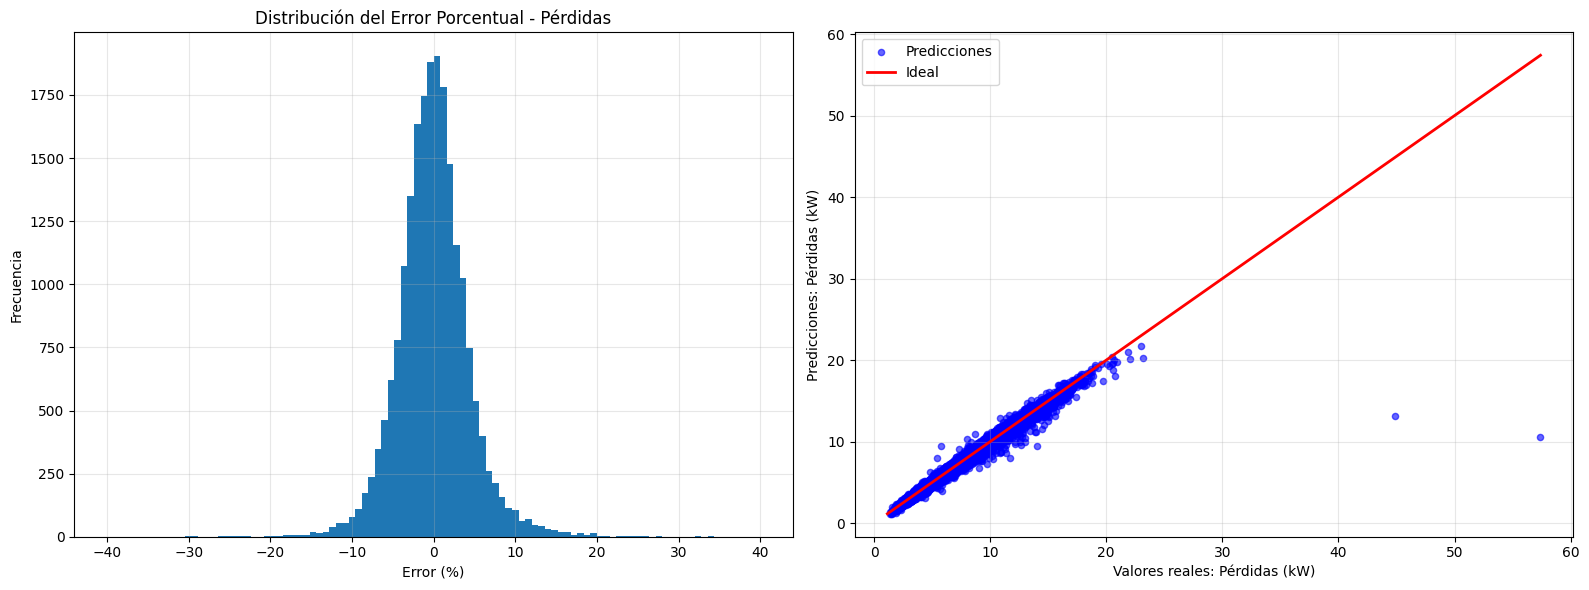

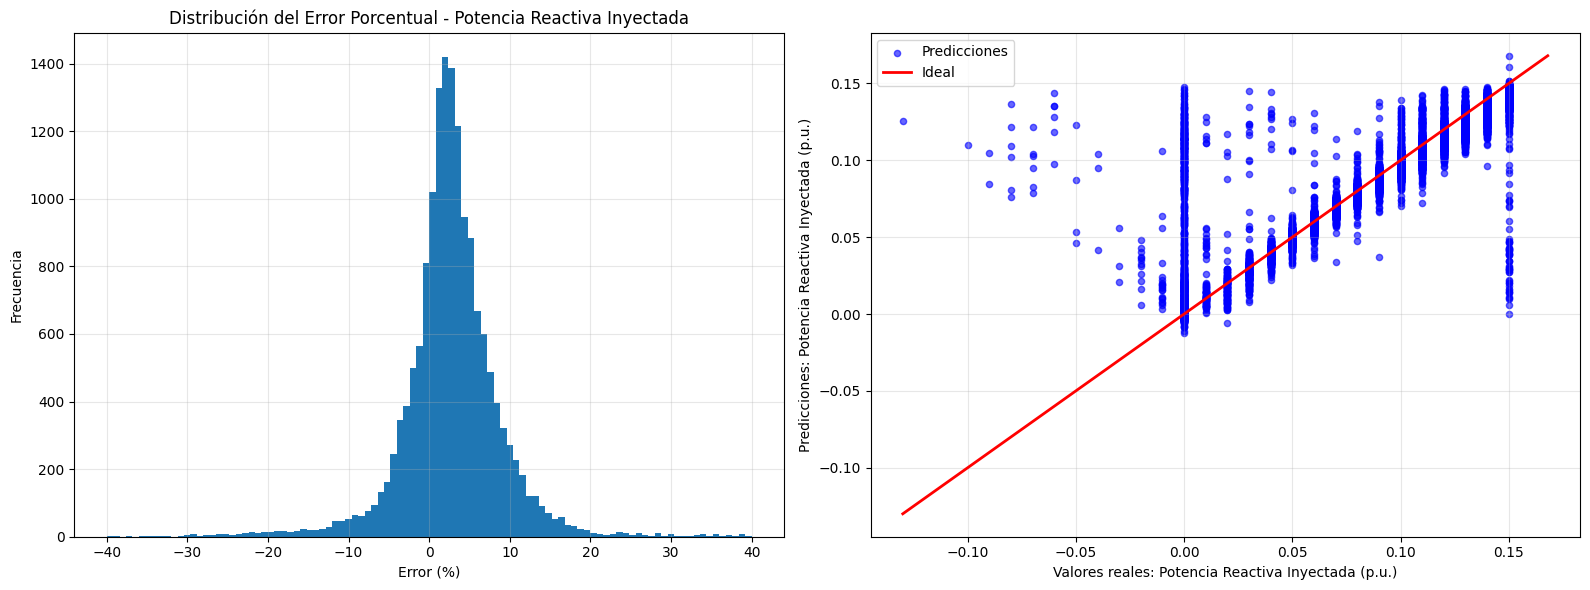

In [18]:
plot_performance_analysis(
    y_test['PERD'],
    grid_predictions[:, -2],
    variable_name="Pérdidas",
    unit_label="kW"
)

plot_performance_analysis(
    y_test['QGEN7'],
    grid_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u."
)